# **Concentration and Diversity in Collaboration Networks in Electrical Engineering: Evidence from Brazilian Researchers**

---

### **Authors**

- **Fernando A. do Carmo**  
  ORCID: https://orcid.org/0000-0003-4594-5924  

- **Gustavo S. Silva**  
  ORCID: https://orcid.org/0009-0001-1559-3465  

- **Raimundo C. S. Freire**  
  ORCID: https://orcid.org/0000-0002-5395-7143  

- **Antonio F. L. Jacob Jr**  
  ORCID: https://orcid.org/0000-0002-9415-7265  

- **Fábio M. F. Lobato**  
  ORCID: https://orcid.org/0000-0002-6282-0368  

---

<br>

#### **Notes on Supplementary Material**

This notebook contains the computational procedures, data analysis, and reproducibility materials associated with the article. All figures and tables generated here correspond to results discussed in the main manuscript.



# Data

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
articles_path = None
df_articles = pd.read_parquet(articles_path)

print(f"{df_articles.shape=}")
print("columns:", df_articles.columns)

df_articles.shape=(7891, 5)
columns: Index(['titulo', 'ano', 'periodico', 'autores', 'authors_ids'], dtype='object')


# Topic Modeling

In [ ]:
titles = df_articles.titulo.to_list()
titles[-3:]

['Influence Of A Direct-Conversion Receiver Model On The Performance Of Detectors For Spectrum Sensing',
 'Resource-Efficient Low-Latency Modified Pietra-Ricci Index Detector For Spectrum Sensing In Cognitive Radio Networks',
 'Design Of Time-Varying Controllers For Discrete-Time Linear Systems With Input Saturation.']

### Topic Modeling

In [ ]:
from sentence_transformers import SentenceTransformer

model = "paraphrase-multilingual-mpnet-base-v2"
embedding_model = SentenceTransformer(model)

In [ ]:
embeddings = embedding_model.encode(titles, show_progress_bar=True)
embeddings.shape

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

(7891, 768)

In [ ]:
import cuml
cuml.accel.install()

In [ ]:
from cuml.manifold import UMAP

umap_model = UMAP(
    n_neighbors=11,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=2025
)

[2026-01-20 15:57:12.399] [CUML] [info] build_algo set to brute_force_knn because random_state is given


In [ ]:
reduced_embeddings = umap_model.fit_transform(embeddings)
reduced_embeddings.shape

(7891, 5)

In [ ]:
from cuml.cluster import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=25,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
hdbscan_model.fit(reduced_embeddings)

clusters = hdbscan_model.labels_
n_clusters = len(set(clusters))

print(f"{n_clusters=}")

n_clusters=53


In [ ]:
def plot_2d_space(
        embeddings: np.ndarray,
        labels: np.ndarray,
        *,
        outlier_label: int = -1,
        savefig: bool = False,
    ) -> None:

    if embeddings.shape[1] != 2:
        raise ValueError("Embeddings must be 2-dimensional.")

    df = pd.DataFrame(embeddings, columns=["x", "y"])
    df["cluster"] = labels

    inliers = df[df.cluster != outlier_label]
    outliers = df[df.cluster == outlier_label]

    fig, ax = plt.subplots(figsize=(10, 6))

    if not outliers.empty:
        ax.scatter(
            outliers.x, outliers.y, marker="x", alpha=0.1, s=2,
            c="grey", label="outliers"
        )

        ax.scatter(
            inliers.x, inliers.y, c=inliers.cluster.astype(int),
            alpha=0.6, s=10, cmap="tab20b"
        )

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        if savefig:
            plt.savefig("2d_projections.png", dpi=300, bbox_inches="tight")

        plt.show()

[2026-01-20 15:57:26.051] [CUML] [info] build_algo set to brute_force_knn because random_state is given


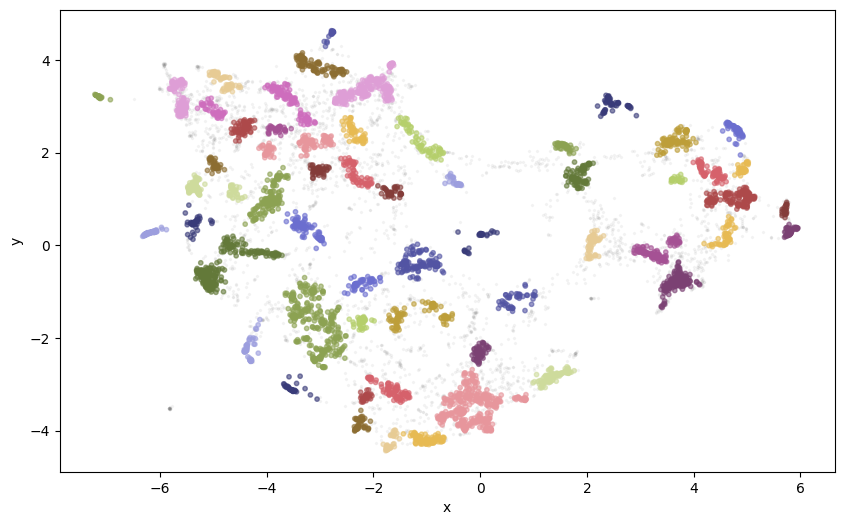

In [ ]:
reduced_embeddings_2d = UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=2025
).fit_transform(embeddings)

hdbscan_model.fit(reduced_embeddings_2d)
clusters = hdbscan_model.labels_

plot_2d_space(reduced_embeddings_2d, clusters)

In [ ]:
# ⚠️ GPU Required! ⚠️

!pip install -q bertopic datamapplot

In [ ]:
# https://github.com/abetlen/llama-cpp-python/issues/1535
!CMAKE_ARGS="-DGGML_CUDA=on -DCMAKE_CUDA_ARCHITECTURES=75" pip install \
     --no-cache-dir llama-cpp-python==0.2.77 \
     --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

In [ ]:
!wget https://huggingface.co/TheBloke/OpenHermes-2.5-Mistral-7B-GGUF/resolve/main/openhermes-2.5-mistral-7b.Q5_K_M.gguf

In [ ]:
from llama_cpp import Llama

from bertopic import BERTopic
from bertopic.representation import (
    KeyBERTInspired,
    MaximalMarginalRelevance,
    LlamaCPP
)

In [ ]:
llm = Llama(
    model_path="openhermes-2.5-mistral-7b.Q5_K_M.gguf",
    n_gpu_layers=-1,
    n_ctx=512,
    stop=["Q:", "\n"]
)

In [ ]:
prompt = """ Q:
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the above information, can you give a short label of the topic of at most 5 words?
A:
"""

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    representation_model={
        "KeyBERT": KeyBERTInspired(),
        "MMR": MaximalMarginalRelevance(diversity=0.2),
        "LLM": LlamaCPP(llm, prompt=prompt)
    },
    verbose=True
)

In [ ]:
# topics, probs = topic_model.fit_transform(titles, embeddings)

# loads the trained model
bertopic_model_path = None
topic_model = BERTopic.load(bertopic_model_path)
topics, probs = topic_model.transform(titles)

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

2026-01-20 15:58:39,153 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


In [ ]:
topic_model.visualize_barchart(top_n_topics=12)

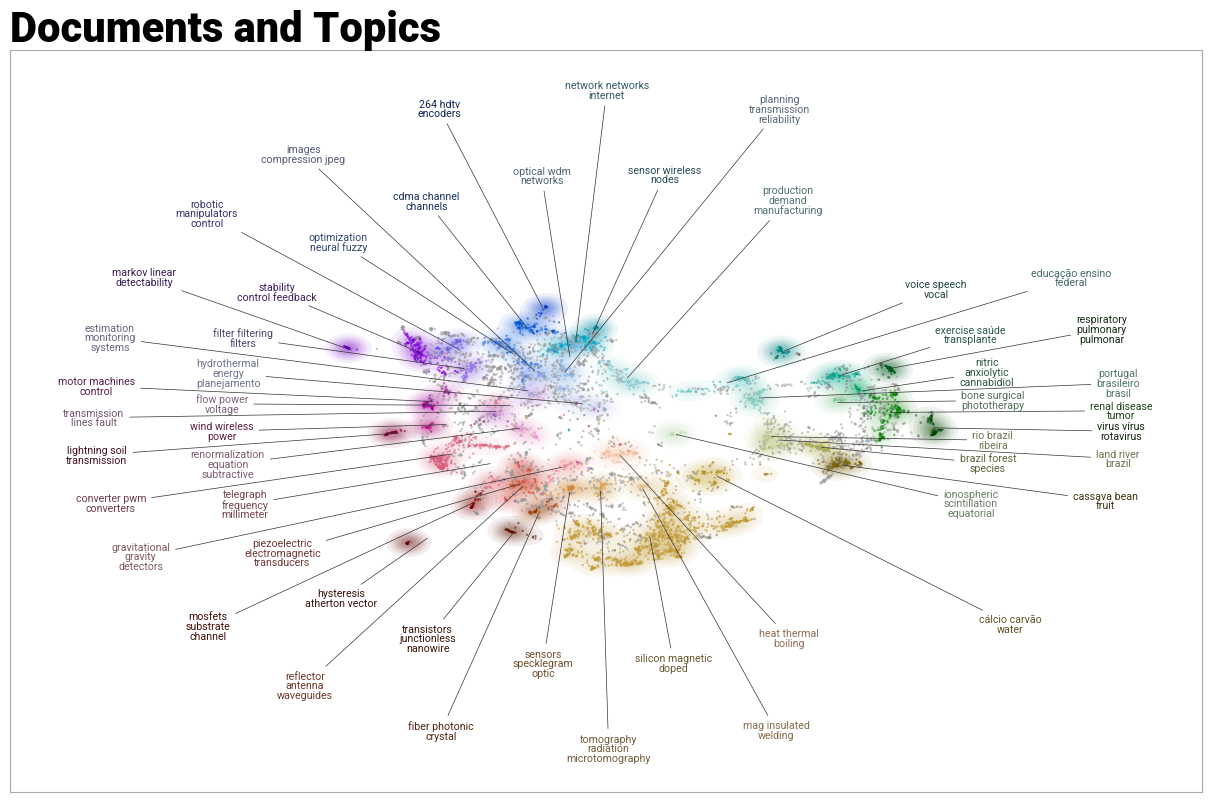

In [ ]:
fig = topic_model.visualize_document_datamap(
    titles,
    reduced_embeddings=reduced_embeddings_2d,
    width=1200,
)

In [ ]:
import re

def clean_label(raw_label: str) -> str:
    """Normalize LLM-generated topic labels."""
    label = raw_label.split("\n", 1)[0].replace('"', '')
    label = re.sub(r'\W+', ' ', label).strip()
    return label or "Unlabelled"


topics_dict = topic_model.get_topics(full=True)["LLM"]

llm_labels = [
    clean_label(topic[0][0])
    for topic in topics_dict.values()
]

all_labels = np.array([
    llm_labels[topic + topic_model._outliers] if topic != -1 else "Unlabelled"
    for topic in topics
])

In [ ]:
np.unique(all_labels)

array(['Adaptive DS Cdma Channels and MIMO Receivers',
       'Adaptive Filtering Algorithms', 'Anxiolytic Effects in Rat Brain',
       'Brazilian Forest Species',
       'Brazilian Gravitational Wave Detector',
       'Brazilian Immigration to Portugal',
       'Disease and Infections Treatment',
       'Education and Teacher Training in Brazil',
       'Energy Scheduling and Optimization',
       'Fiber Raman Lasers and Amplifiers',
       'Flow Boiling Heat Transfer in Tubes',
       'Geology of Brazilian Formations',
       'Hybrid Investor Project Methodology',
       'Ice cream additives effects', 'Image Compression Techniques',
       'Induction Motor Control Systems',
       'Ionospheric Scintillation GPS Amplitude',
       'Jiles Atherton Vector Hysteresis Modeling',
       'Junctionless Nanowire Transistors',
       'Laser Phototherapy in Bone Regeneration',
       'Lightning Performance of Transmission Lines and Grounding',
       'Low Frequency Noise in Semiconductor Devic

In [ ]:
threshold = 30

label_sizes = pd.Series(all_labels).value_counts()

filtered_labels = all_labels.copy()
filtered_labels[filtered_labels == "Unlabelled"] = "No Topic"
filtered_labels[np.isin(filtered_labels, label_sizes[label_sizes < threshold].index)] = "No Topic"

In [ ]:
import datamapplot
from matplotlib import cm

def plot_2d_space_datamapplot(embeddings, labels) -> None:
    datamapplot.create_plot(
        embeddings,
        labels,
        noise_label="No Topic",
        label_font_size=9,
        title="IEEE-LATAM - BERTopic",
        sub_title="Topics labeled with `paraphrase-multilingual-mpnet-base-v2`",
        label_wrap_width=10,
        use_medoids=True,
        cmap=cm.viridis
    )

    return None

Calculating medoids: 100%|██████████| 50/50 [00:07<00:00,  6.80it/s]


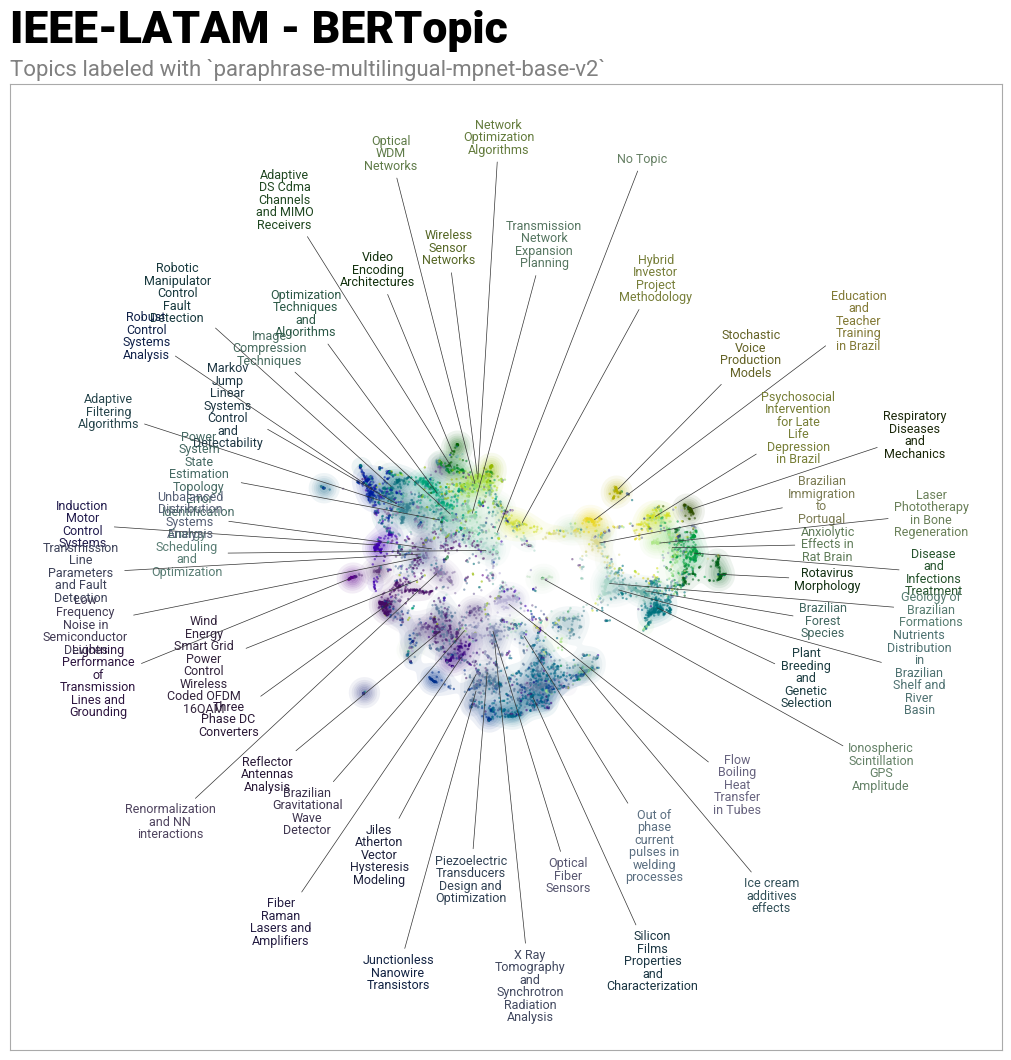

In [ ]:
plot_2d_space_datamapplot(reduced_embeddings_2d, filtered_labels)

In [ ]:
# list extracted manually by the authors

CNPQ_EE_MAPPING = {
    "Adaptive DS Cdma Channels and MIMO Receivers": "Telecommunications",
    "Adaptive Filtering Algorithms": "Industrial Electronics, Electronic Systems and Control",
    "Brazilian Gravitational Wave Detector": "Telecommunications",
    "Energy Scheduling and Optimization": "Power Systems",
    "Fiber Raman Lasers and Amplifiers": "Telecommunications",
    "Image Compression Techniques": "Electrical, Magnetic and Electronic Circuits",
    "Induction Motor Control Systems": "Industrial Electronics, Electronic Systems and Control",
    "Ionospheric Scintillation GPS Amplitude": "Telecommunications",
    "Jiles Atherton Vector Hysteresis Modeling": "Industrial Electronics, Electronic Systems and Control",
    "Junctionless Nanowire Transistors": "Electrical Materials",
    "Lightning Performance of Transmission Lines and Grounding": "Power Systems",
    "Low Frequency Noise in Semiconductor Devices": "Electrical Materials",
    "Markov Jump Linear Systems Control and Detectability": "Industrial Electronics, Electronic Systems and Control",
    "Network Optimization Algorithms": "Industrial Electronics, Electronic Systems and Control",
    "Optical Fiber Sensors": "Electrical, Magnetic and Electronic Measurements",
    "Optical WDM Networks": "Telecommunications",
    "Optimization Techniques and Algorithms": "Industrial Electronics, Electronic Systems and Control",
    "Piezoelectric Transducers Design and Optimization": "Industrial Electronics, Electronic Systems and Control",
    "Power System State Estimation Topology Error Identification": "Power Systems",
    "Reflector Antennas Analysis": "Telecommunications",
    "Robotic Manipulator Control Fault Detection": "Industrial Electronics, Electronic Systems and Control",
    "Robust Control Systems Analysis": "Industrial Electronics, Electronic Systems and Control",
    "SOI MOSFETs and Temperature Effects": "Electrical Materials",
    "Silicon Films Properties and Characterization": "Electrical Materials",
    "Three Phase DC Converters": "Industrial Electronics, Electronic Systems and Control",
    "Transmission Line Parameters and Fault Detection": "Power Systems",
    "Transmission Network Expansion Planning": "Power Systems",
    "Unbalanced Distribution Systems Analysis": "Power Systems",
    "Video Encoding Architectures": "Telecommunications",
    "Wind Energy Smart Grid Power Control Wireless Coded OFDM 16QAM": "Telecommunications",
    "Wireless Sensor Networks": "Telecommunications",
    "X Ray Tomography and Synchrotron Radiation Analysis": "Electrical, Magnetic and Electronic Measurements",
}

In [ ]:
(
    pd.Series(all_labels, name="labels")
    .map(CNPQ_EE_MAPPING)
    .fillna("No Topic")
    .value_counts()
)

,count
labels,
No Topic,2478
"Industrial Electronics, Electronic Systems and Control",2436
Telecommunications,883
Electrical Materials,846
Power Systems,822
"Electrical, Magnetic and Electronic Measurements",351
"Electrical, Magnetic and Electronic Circuits",75


In [ ]:
ee_related = list(CNPQ_EE_MAPPING.keys())

In [ ]:
ee_topic_labels = all_labels.copy()
ee_topic_labels[~np.isin(ee_topic_labels, ee_related)] = "No Topic"

Calculating medoids: 100%|██████████| 32/32 [00:00<00:00, 1615.76it/s]


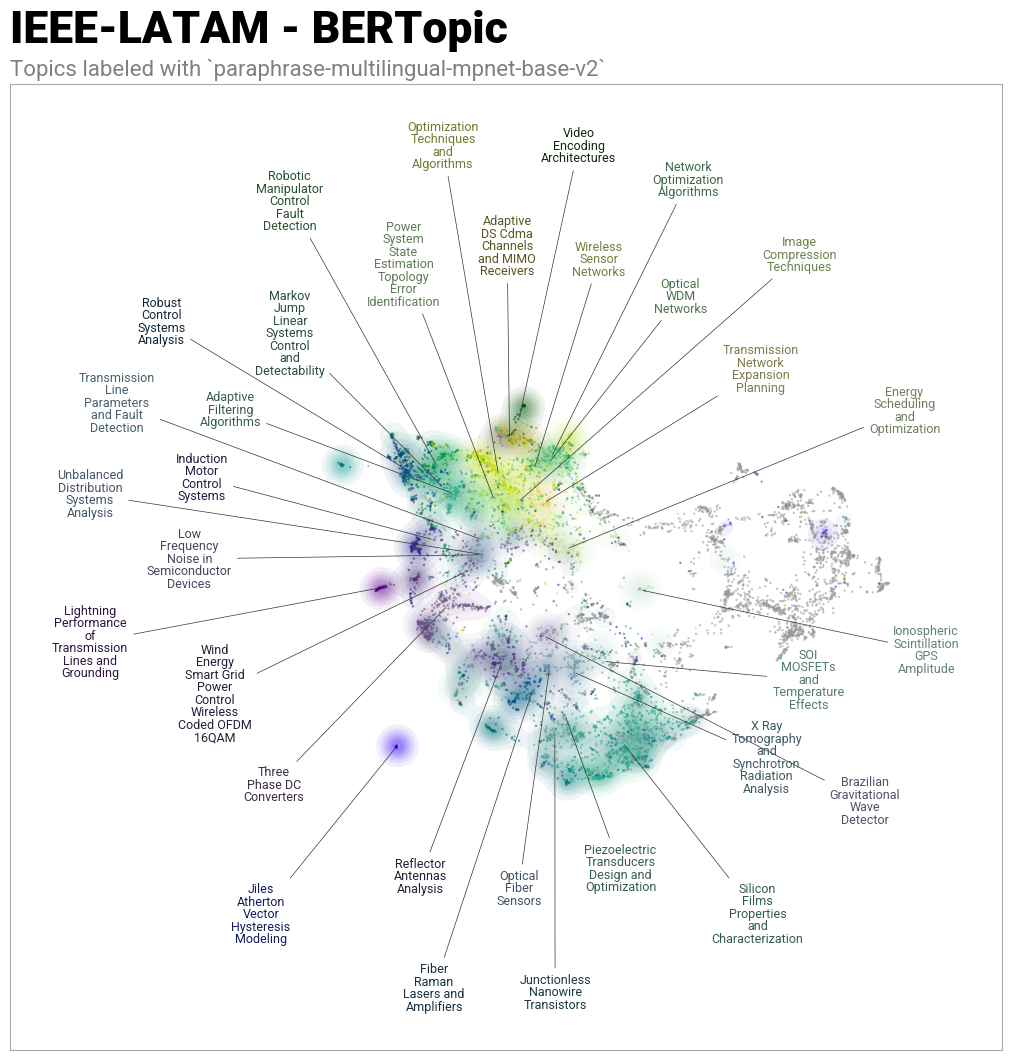

In [ ]:
plot_2d_space_datamapplot(reduced_embeddings_2d, ee_topic_labels)

In [ ]:
topic_model.visualize_heatmap()

In [ ]:
topic_model.visualize_term_rank()

In [ ]:
# df_topics = pd.read_parquet(topics_path)
# df_articles = pd.read_parquet(articles_path)

df_topics = (
    df_topics
    .assign(
        MMR_repr=lambda df: df.Topic.astype(str) + "_" + df.MMR.str.join("_"),
        KeyBERT_repr=lambda df: df.Topic.astype(str) + "_" + df.KeyBERT.str.join("_")
    )
)

df_articles = (
    df_articles
    .merge(
        df_topics,
        how="left",
        left_on="titulo",
        right_on="Document"
    )
)

In [ ]:
from collections import defaultdict

topic_collaborations = defaultdict(list)
topic_authors = defaultdict(set)

for index, record in df_articles.iterrows():
    if pd.isna(record.get("authors_ids")) or pd.isna(record.get("Topic")):
        continue

    authors = record.authors_ids.split(";")
    topic = record.Topic
    topic_name = record.get("Name", f"Topic_{topic}")

    # filter for EE authors
    ee_authors = [a for a in authors if a.startswith("X")]
    if len(ee_authors) < 2:
        continue

    topic_collaborations[topic_name].append(len(ee_authors))
    topic_authors[topic_name].update(ee_authors)

In [ ]:
df_topic_collaboration_summary = pd.DataFrame({
    "topic": topic_collaborations.keys(),
    "num_papers": [len(v) for v in topic_collaborations.values()],
    "avg_authors_per_paper": [np.mean(v) for v in topic_collaborations.values()],
    "total_authors": [len(topic_authors[k]) for k in topic_collaborations],
    "total_collaborations": [sum(v) for v in topic_collaborations.values()],
})

df_topic_collaboration_summary = (
    df_topic_collaboration_summary
    .sort_values("num_papers", ascending=False)
    .iloc[1:]
)

In [ ]:
from matplotlib import lines

top_10_topics_df = df_topic_collaboration_summary.sort_values(by="num_papers", ascending=False).head(11)
top_10_topic_names = top_10_topics_df["topic"].unique()
other_topics_df = df_topic_collaboration_summary[~df_topic_collaboration_summary["topic"].isin(top_10_topic_names)]

scatter_cmap = plt.get_cmap("tab10", 11) # 10 distinct colors for top topics
topic_to_color_map = {topic: scatter_cmap(i) for i, topic in enumerate(top_10_topic_names)}

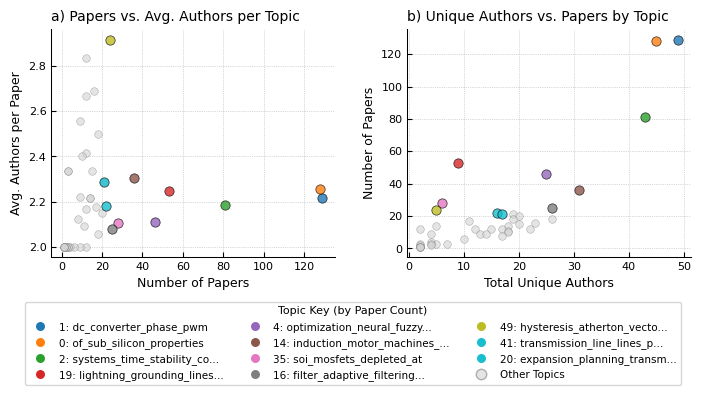

In [ ]:
fig, axs = plt.subplots(
    nrows=1, ncols=2, figsize=(7.2, 3.8)
)

axs[0].scatter(
    other_topics_df["num_papers"], other_topics_df["avg_authors_per_paper"],
    alpha=0.6, color="lightgray", s=30, edgecolors="gray", linewidth=0.4, zorder=5
)

for topic_name in top_10_topic_names:
    topic_subset = top_10_topics_df[top_10_topics_df["topic"] == topic_name]
    if not topic_subset.empty:
        axs[0].scatter(
            topic_subset["num_papers"], topic_subset["avg_authors_per_paper"],
            alpha=0.8, color=topic_to_color_map[topic_name],
            s=45, edgecolors="black", linewidth=0.5, zorder=10
        )

axs[0].set_title("a) Papers vs. Avg. Authors per Topic", fontsize=10, loc="left", pad=6)
axs[0].set_xlabel("Number of Papers", fontsize=9)
axs[0].set_ylabel("Avg. Authors per Paper", fontsize=9)


axs[1].scatter(
    other_topics_df["total_authors"], other_topics_df["num_papers"],
    alpha=0.6, color="lightgray", s=30, edgecolors="gray", linewidth=0.4, zorder=5
)

for topic_name in top_10_topic_names:
    topic_subset = top_10_topics_df[top_10_topics_df["topic"] == topic_name]
    if not topic_subset.empty:
        axs[1].scatter(
            topic_subset["total_authors"], topic_subset["num_papers"],
            alpha=0.8, color=topic_to_color_map[topic_name],
            s=45, edgecolors="black", linewidth=0.5, zorder=10
        )

axs[1].set_title("b) Unique Authors vs. Papers by Topic", fontsize=10, loc="left", pad=6)
axs[1].set_xlabel("Total Unique Authors", fontsize=9)
axs[1].set_ylabel("Number of Papers", fontsize=9)


# common axis formatting
for ax_item in axs:
    ax_item.grid(True, linestyle=":", color="gray", alpha=0.6, linewidth=0.5, axis="both")
    ax_item.tick_params(axis="both", which="major", labelsize=8, direction="in", pad=3)
    ax_item.spines[["top", "right"]].set_visible(False)
    ax_item.spines[["left", "bottom"]].set_linewidth(0.75)


legend_elements_scatter = []
# legend handles for the top 10 topics
for topic_name in top_10_topic_names:
    topic_id_str, topic_keywords_str = topic_name.split('_', 1)
    legend_label = f"{topic_id_str}: {topic_keywords_str[:25]}"
    if len(topic_keywords_str) > 25: legend_label += "..."

    legend_elements_scatter.append(
        lines.Line2D([0], [0], marker='o', color='w',
        label=legend_label, markerfacecolor=topic_to_color_map[topic_name],
        markersize=7.5)
    )

# legend handle for "Other Topics"
legend_elements_scatter.append(
    lines.Line2D([0], [0], marker='o', color='w',
    label="Other Topics", markerfacecolor="lightgray",
    markeredgecolor='gray', alpha=0.6, markersize=7.5)
)


fig.subplots_adjust(left=0.08, right=0.97, bottom=0.30, top=0.90, wspace=0.25)
fig.legend(
    handles=legend_elements_scatter,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    fontsize=7.5,
    title="Topic Key (by Paper Count)",
    title_fontsize=7.5 + 0.5,
    frameon=True, fancybox=True
)

plt.show()

In [ ]:
def get_short_topic_labels(series, topics_only=False) -> list:
    if topics_only:
        short_labels = [
            f"{t.split("_", 1)[0]}"
            for t in series
        ]

    else:
        short_labels = [
            f"{t.split("_", 1)[0]}: {t.split("_", 1)[1][:20]}..."
            if "_" in t and len(t)>40 else t[:40]
            for t in series
        ]

    return short_labels

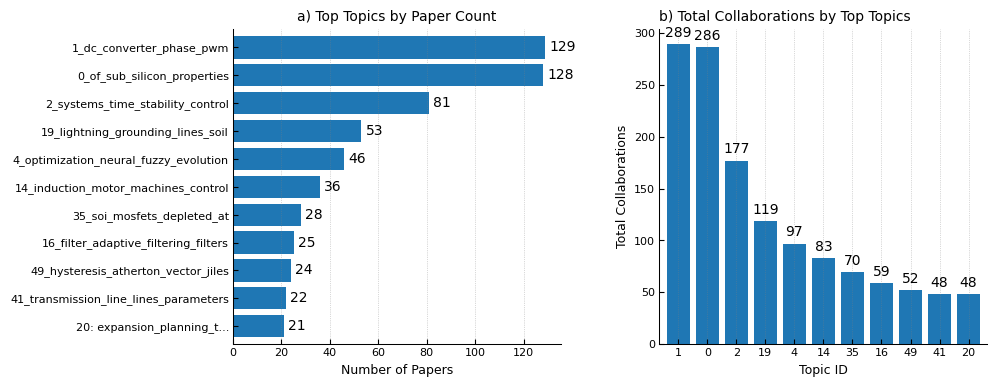

In [ ]:
fig, axs = plt.subplots(
    nrows=1, ncols=2, figsize=(9.2, 4.2)
)

short_labels_0 = get_short_topic_labels(top_10_topics_df["topic"])

bars = top_10_topics_df["num_papers"].plot(kind="barh", ax=axs[0], width=0.8)
axs[0].bar_label(bars.containers[0], fmt="%.0f", padding=3)
axs[0].set_yticklabels(short_labels_0, fontsize=7)
axs[0].set_title("a) Top Topics by Paper Count", fontsize=10, loc="center", pad=6)
axs[0].set_xlabel("Number of Papers", fontsize=9)
axs[0].invert_yaxis()


short_labels_1 = get_short_topic_labels(top_10_topics_df["topic"], topics_only=True)

bars = top_10_topics_df["total_collaborations"].sort_values(ascending=False).plot(kind="bar", ax=axs[1], width=0.8)
axs[1].bar_label(bars.containers[0], fmt="%.0f", padding=3)
axs[1].set_xticklabels(short_labels_1, fontsize=7, rotation=0)
axs[1].set_title("b) Total Collaborations by Top Topics", fontsize=10, loc="left", pad=6)
axs[1].set_xlabel("Topic ID", fontsize=9)
axs[1].set_ylabel("Total Collaborations", fontsize=9)


# common axis formatting
for ax in axs:
    ax.tick_params(axis="x", which="major", labelsize=8, direction="in", pad=3)
    ax.tick_params(axis="y", which="major", labelsize=8, direction="in", pad=3)
    ax.grid(True, linestyle=":", color="gray", alpha=0.6, linewidth=0.5, axis="x")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.75)


fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.90, wspace=0.3)
plt.show()

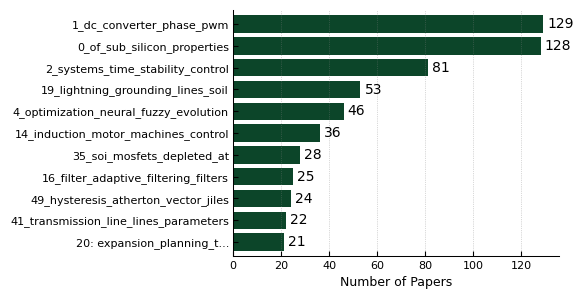

In [ ]:
_, ax = plt.subplots(figsize=(4.2, 3.2))

short_labels_a = [
    f"{t.split("_",1)[0]}: {t.split("_",1)[1][:20]}..."
    if "_" in t and len(t)>40 else t[:40]
    for t in top_10_topics_df["topic"]
]

bars = top_10_topics_df["num_papers"].plot(kind="barh", ax=ax, color="#0c4529", width=0.8)

ax.bar_label(bars.containers[0], fmt="%.0f", padding=3)
ax.set_yticklabels(short_labels_a, fontsize=7)
ax.set_xlabel("Number of Papers", fontsize=9)
ax.invert_yaxis()

ax.tick_params(axis="x", which="major", labelsize=8, direction="in", pad=3)
ax.tick_params(axis="y", which="major", labelsize=8, direction="in", pad=3)
ax.grid(True, linestyle=":", color="gray", alpha=0.6, linewidth=0.5, axis="x")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(0.75)

In [ ]:
TOP_K = 5

(
    df_articles
    .query("ano in ['2019', '2020', '2021', '2022'] and Topic != -1")
    .groupby(["ano", "Name"])
    .size()
    .sort_index()
    .groupby("ano")
    .nlargest(TOP_K)
    .rename(index="Count")
    .droplevel(1)
)

ano   Name                                 
2019  0_of_sub_silicon_properties              32
      1_dc_converter_phase_pwm                 13
      3_patients_renal_in_disease              11
      6_network_networks_internet_service      10
      18_exercise_saúde_transplante_care        8
2020  0_of_sub_silicon_properties              22
      2_systems_time_stability_control         10
      10_do_da_portugal_brasileiro              8
      18_exercise_saúde_transplante_care        8
      1_dc_converter_phase_pwm                  8
2021  0_of_sub_silicon_properties              15
      23_gravitational_detector_wave_theory     9
      10_do_da_portugal_brasileiro              5
      18_exercise_saúde_transplante_care        5
      19_lightning_grounding_lines_soil         5
2022  0_of_sub_silicon_properties              14
      10_do_da_portugal_brasileiro              8
      26_educação_da_ensino_de                  7
      1_dc_converter_phase_pwm                  6
      12_de_para_production_uma                 5
Name: Count, dtype: int64